# **Section 8: XGBoost Classification**

In this notebook, I will train and evaluate XGBoost (Gradient Boosting) models. XGBoost is particularly well-suited for high-dimensional genomic data with limited samples. I will start with a baseline model and then tune hyperparameters using cross-validated grid search.


## **1. Importing the Data**

Let's import the data and split it into training, validation and test sets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')
sns.set_palette("pastel")

### **1.1 Load Features**

In [2]:
# Load features and labels
cnv_data = pd.read_csv('cnvs_cleaned_SXT.csv', index_col=0)
profiles = pd.read_csv('SXT.csv', index_col=0)

X = cnv_data.values
y = profiles.values

print(f"Data shape: {X.shape}")
print(f"Label shape: {y.shape}")
print(f"Categories: {np.unique(y)}")

Data shape: (221, 8085)
Label shape: (221, 1)
Categories: [0 1]


### **1.2 Split Data into Train, Validation, and Test Sets**

In [3]:
# First split: 70% train+val, 30% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Second split: 70% train (from remaining), 30% val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.3, random_state=42, stratify=y_temp
)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (107, 8085)
Validation set shape: (47, 8085)
Test set shape: (67, 8085)


## **2. XGBoost with Default Hyperparameters**

Let's start with a baseline XGBoost model using default parameters.

In [4]:
# Create XGBoost model (no scaling needed for tree-based models)
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train the model
xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### **2.1 Evaluate Baseline Model**

In [5]:
# Evaluate on training, validation, and test sets
accuracy_train = xgb_model.score(X_train, y_train)
accuracy_val = xgb_model.score(X_val, y_val)
accuracy_test = xgb_model.score(X_test, y_test)

print(f"Accuracy training set: {accuracy_train:.4f}")
print(f"Accuracy validation set: {accuracy_val:.4f}")
print(f"Accuracy test set: {accuracy_test:.4f}")

Accuracy training set: 1.0000
Accuracy validation set: 0.9149
Accuracy test set: 0.9254


### **2.2 Feature Importance (Baseline)**

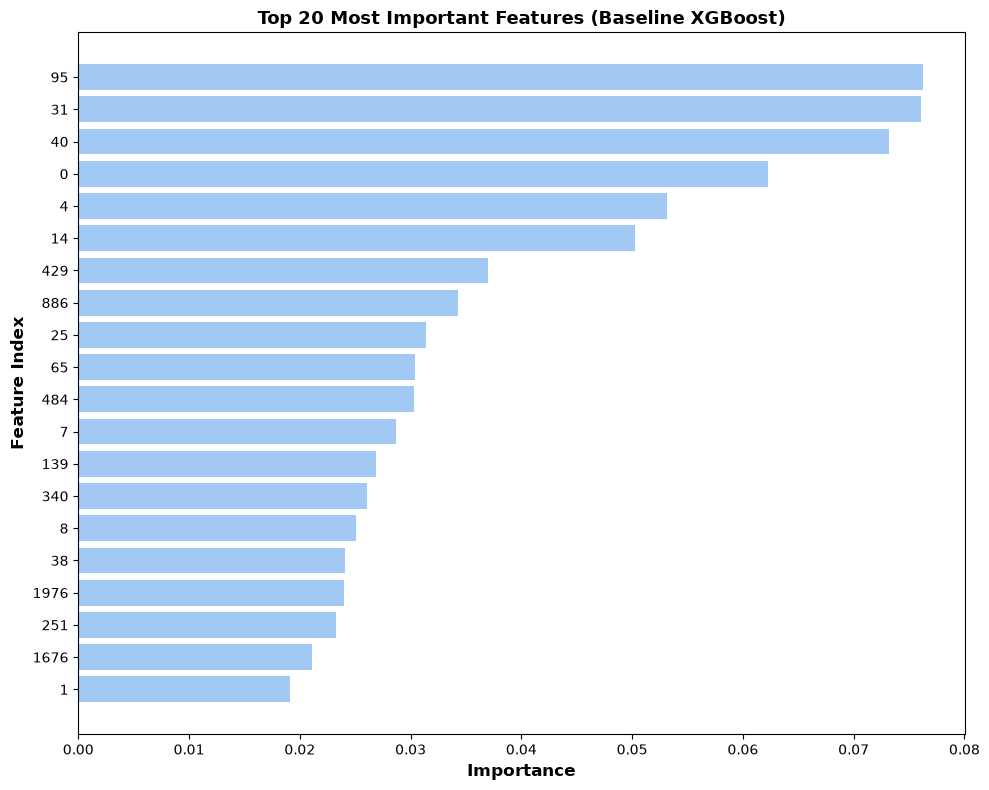


Top 10 most important features:
     feature_index  importance
95              95    0.076228
31              31    0.076042
40              40    0.073211
0                0    0.062277
4                4    0.053146
14              14    0.050286
429            429    0.037017
886            886    0.034294
25              25    0.031424
65              65    0.030435


In [6]:
# Get feature importances
feature_importance = xgb_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature_index': range(len(feature_importance)),
    'importance': feature_importance
}).sort_values('importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(10, 8))
plt.barh(range(20), feature_importance_df['importance'].head(20))
plt.yticks(range(20), feature_importance_df['feature_index'].head(20))
plt.xlabel('Importance', fontsize=12, fontweight='bold')
plt.ylabel('Feature Index', fontsize=12, fontweight='bold')
plt.title('Top 20 Most Important Features (Baseline XGBoost)', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 most important features:")
print(feature_importance_df.head(10))

### **2.3 Classification Report and Confusion Matrix**

In [7]:
# Get predictions
y_test_pred = xgb_model.predict(X_test)

# Classification report
print("Classification Report (Baseline XGBoost):")
print(classification_report(y_test, y_test_pred))

Classification Report (Baseline XGBoost):
              precision    recall  f1-score   support

           0       0.86      1.00      0.93        31
           1       1.00      0.86      0.93        36

    accuracy                           0.93        67
   macro avg       0.93      0.93      0.93        67
weighted avg       0.94      0.93      0.93        67



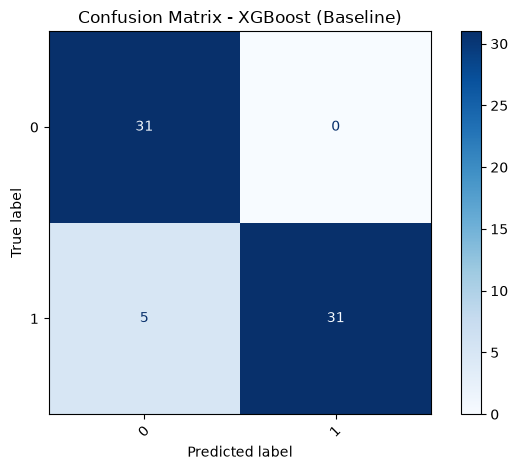

In [8]:
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=xgb_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb_model.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - XGBoost (Baseline)")
plt.tight_layout()
plt.show()

## **3. Hyperparameter Tuning: Optimizing Regularization and Tree Parameters**

Now let's use cross-validated grid search to find optimal hyperparameters.

### **3.1 Combine Training and Validation Sets**

In [9]:
# Combine train and validation sets for grid search
X_train_total = np.vstack([X_train, X_val])
y_train_total = np.concatenate([y_train, y_val])

print(f"Combined training set shape: {X_train_total.shape}")
print(f"Combined training set labels shape: {y_train_total.shape}")

Combined training set shape: (154, 8085)
Combined training set labels shape: (154, 1)


### **3.2 Grid Search for Optimal Hyperparameters**

In [10]:
# Define parameter grid
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'reg_alpha': [0.0, 0.1],  # L1 regularization
    'reg_lambda': [0.1, 1.0]  # L2 regularization
}

# Create grid search
grid_search = GridSearchCV(
    xgb.XGBClassifier(
        n_estimators=100,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0,
        use_label_encoder=False,
        eval_metric='logloss'
    ),
    param_grid,
    cv=5,
    return_train_score=True,
    n_jobs=-1
)

# Perform grid search
print("Performing grid search")
grid_search.fit(X_train_total, y_train_total)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

Performing grid search

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'reg_alpha': 0.1, 'reg_lambda': 1.0}
Best cross-validation score: 0.9286


### **3.3 Analyze Grid Search Results**

In [11]:
# Extract results
cv_results = pd.DataFrame(grid_search.cv_results_)

# Display top results
results_display = cv_results[[
    'mean_test_score', 'std_test_score', 
    'mean_train_score', 'std_train_score',
    'param_max_depth', 'param_learning_rate', 'param_reg_alpha', 'param_reg_lambda'
]].sort_values('mean_test_score', ascending=False).head(10)

print("\nTop 10 Grid Search Results:")
print(results_display)


Top 10 Grid Search Results:
    mean_test_score  std_test_score  mean_train_score  std_train_score  \
15         0.928602        0.047359               1.0              0.0   
23         0.928602        0.047359               1.0              0.0   
19         0.928602        0.047359               1.0              0.0   
0          0.928172        0.038962               1.0              0.0   
18         0.928172        0.052600               1.0              0.0   
2          0.928172        0.038962               1.0              0.0   
1          0.928172        0.038962               1.0              0.0   
4          0.928172        0.038962               1.0              0.0   
10         0.928172        0.038962               1.0              0.0   
9          0.928172        0.038962               1.0              0.0   

    param_max_depth  param_learning_rate  param_reg_alpha  param_reg_lambda  
15                3                 0.10              0.1               1.0  


### **3.4 Visualize Learning Rate Effect**

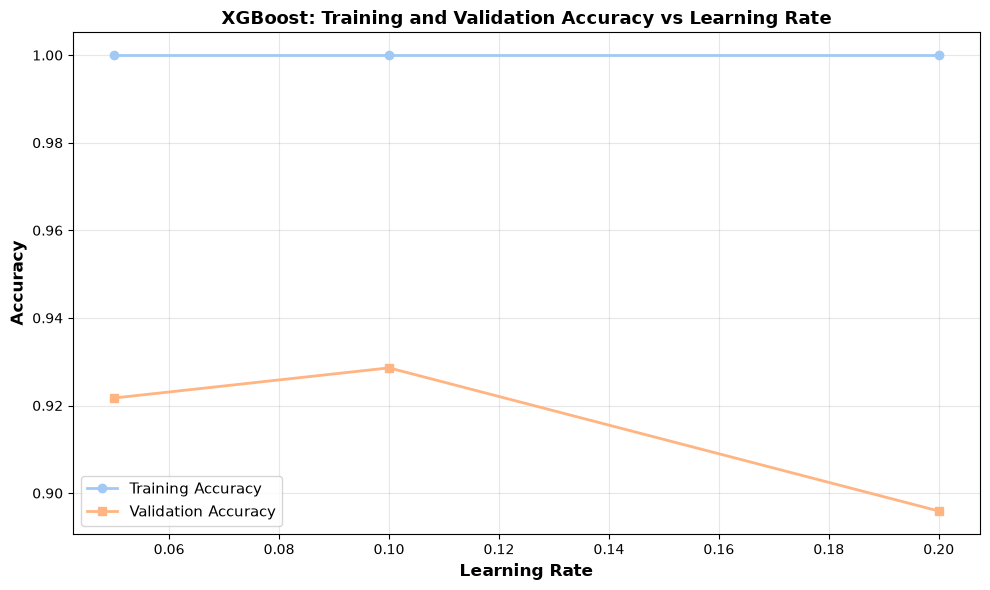

In [12]:
# Filter results for best max_depth
best_max_depth = grid_search.best_params_['max_depth']
best_reg_alpha = grid_search.best_params_['reg_alpha']
best_reg_lambda = grid_search.best_params_['reg_lambda']

filtered_results = cv_results[
    (cv_results['param_max_depth'] == best_max_depth) &
    (cv_results['param_reg_alpha'] == best_reg_alpha) &
    (cv_results['param_reg_lambda'] == best_reg_lambda)
].sort_values('param_learning_rate')

if len(filtered_results) > 0:
    plt.figure(figsize=(10, 6))
    plt.plot(
        filtered_results['param_learning_rate'],
        filtered_results['mean_train_score'],
        label='Training Accuracy',
        marker='o',
        linewidth=2
    )
    plt.plot(
        filtered_results['param_learning_rate'],
        filtered_results['mean_test_score'],
        label='Validation Accuracy',
        marker='s',
        linewidth=2
    )
    
    plt.xlabel('Learning Rate', fontsize=12, fontweight='bold')
    plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
    plt.title('XGBoost: Training and Validation Accuracy vs Learning Rate', fontsize=13, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## **4. Evaluate Best Model**

In [13]:
# Evaluate best model on test set
best_xgb = grid_search.best_estimator_
accuracy_test_best = best_xgb.score(X_test, y_test)

print(f"\nBest Model Test Accuracy: {accuracy_test_best:.4f}")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")


Best Model Test Accuracy: 0.9254
Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'reg_alpha': 0.1, 'reg_lambda': 1.0}
Best CV score: 0.9286


### **4.1 Feature Importance of Best Model**

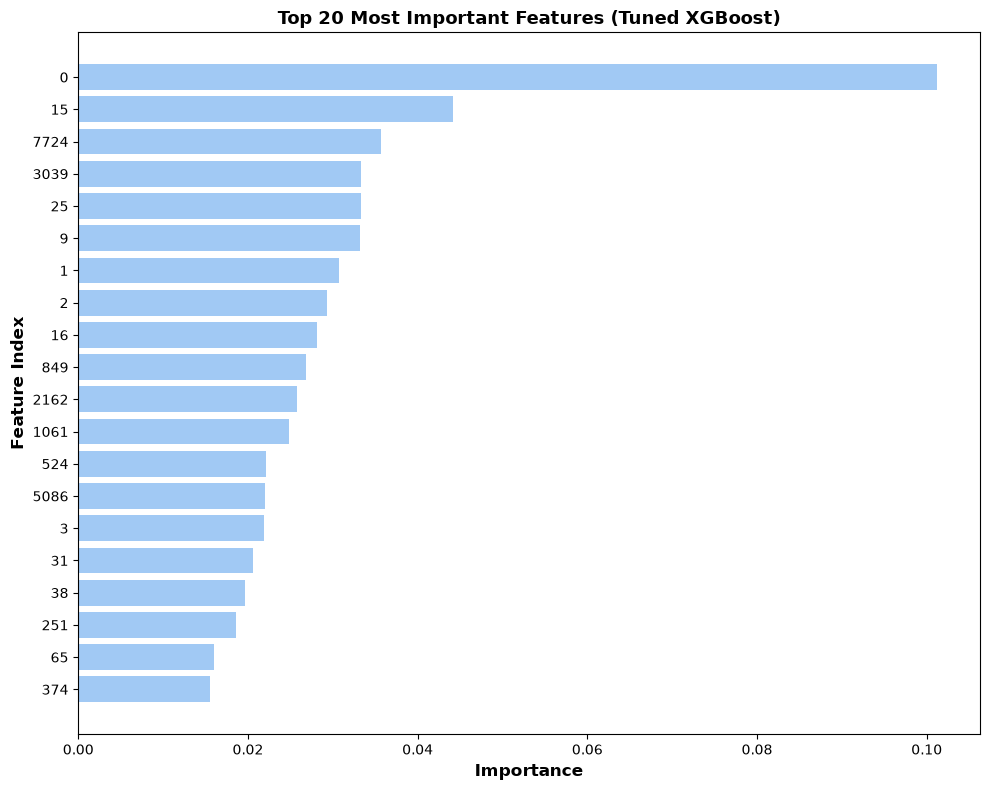


Top 10 most important features (tuned model):
      feature_index  importance
0                 0    0.101219
15               15    0.044125
7724           7724    0.035738
3039           3039    0.033325
25               25    0.033271
9                 9    0.033183
1                 1    0.030758
2                 2    0.029353
16               16    0.028151
849             849    0.026790


In [14]:
# Get feature importances
feature_importance_best = best_xgb.feature_importances_
feature_importance_best_df = pd.DataFrame({
    'feature_index': range(len(feature_importance_best)),
    'importance': feature_importance_best
}).sort_values('importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(10, 8))
plt.barh(range(20), feature_importance_best_df['importance'].head(20))
plt.yticks(range(20), feature_importance_best_df['feature_index'].head(20))
plt.xlabel('Importance', fontsize=12, fontweight='bold')
plt.ylabel('Feature Index', fontsize=12, fontweight='bold')
plt.title('Top 20 Most Important Features (Tuned XGBoost)', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 most important features (tuned model):")
print(feature_importance_best_df.head(10))

### **4.2 Classification Report**

In [15]:
# Get predictions
y_test_pred_best = best_xgb.predict(X_test)

# Classification report
print("\nClassification Report (Best XGBoost):")
print(classification_report(y_test, y_test_pred_best))


Classification Report (Best XGBoost):
              precision    recall  f1-score   support

           0       0.91      0.94      0.92        31
           1       0.94      0.92      0.93        36

    accuracy                           0.93        67
   macro avg       0.92      0.93      0.93        67
weighted avg       0.93      0.93      0.93        67



### **4.3 Confusion Matrix**

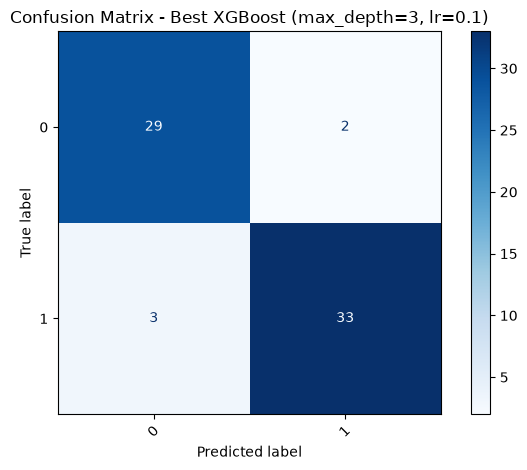

In [16]:
# Confusion matrix
cm_best = confusion_matrix(y_test, y_test_pred_best, labels=best_xgb.classes_)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=best_xgb.classes_)
disp_best.plot(cmap="Blues", xticks_rotation=45)
plt.title(f"Confusion Matrix - Best XGBoost (max_depth={grid_search.best_params_['max_depth']}, lr={grid_search.best_params_['learning_rate']})")
plt.tight_layout()
plt.show()

### **4.4 ROC Curve and AUC Score**

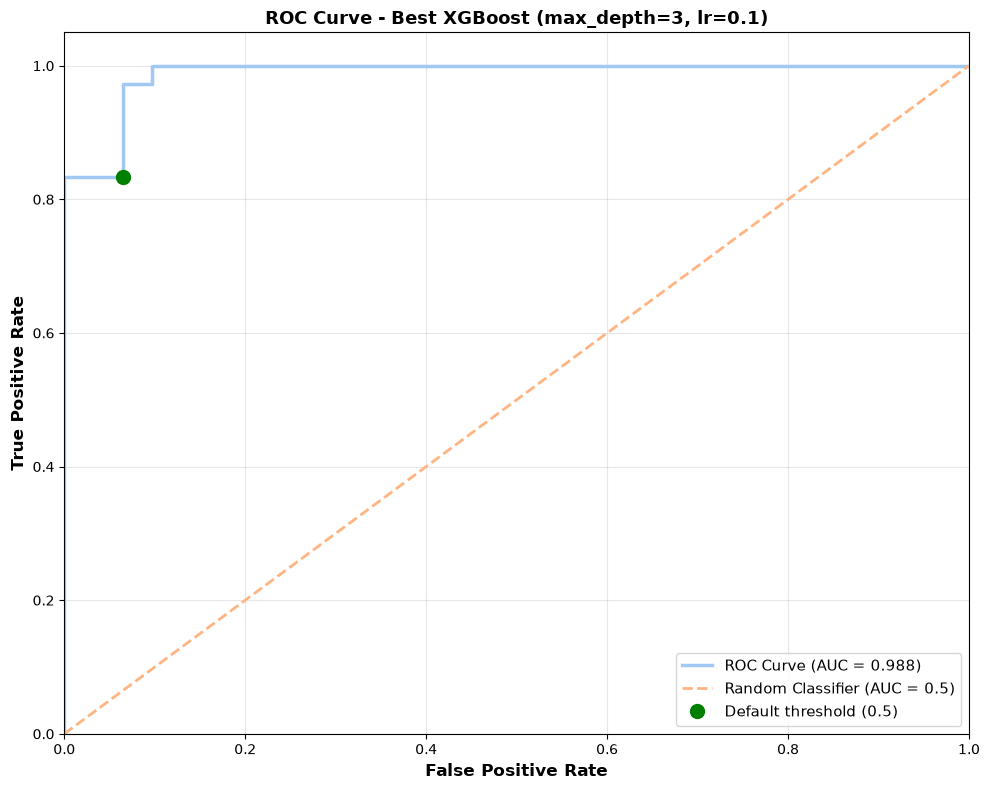


AUC Score: 0.9884
At default threshold (0.5):
  True Positive Rate (TPR): 0.833 (catch 83.3% of resistant)
  False Positive Rate (FPR): 0.065 (6.5% of susceptible misclassified)


In [17]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Get probability predictions for the positive class
y_test_proba = best_xgb.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], lw=2, linestyle='--', label='Random Classifier (AUC = 0.5)')

# Mark the default threshold (0.5)
default_idx = np.argmin(np.abs(thresholds - 0.5))
plt.plot(fpr[default_idx], tpr[default_idx], 'go', markersize=10, label='Default threshold (0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title(f'ROC Curve - Best XGBoost (max_depth={grid_search.best_params_["max_depth"]}, lr={grid_search.best_params_["learning_rate"]})', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nAUC Score: {roc_auc:.4f}")
print(f"At default threshold (0.5):")
print(f"  True Positive Rate (TPR): {tpr[default_idx]:.3f} (catch {tpr[default_idx]*100:.1f}% of resistant)")
print(f"  False Positive Rate (FPR): {fpr[default_idx]:.3f} ({fpr[default_idx]*100:.1f}% of susceptible misclassified)")

## **5. Save Results**

In [18]:
import csv
import os

# Store results
results = {
    'model': 'XGBoost',
    'hyperparameters': f"max_depth={grid_search.best_params_['max_depth']}, learning_rate={grid_search.best_params_['learning_rate']}, reg_alpha={grid_search.best_params_['reg_alpha']}, reg_lambda={grid_search.best_params_['reg_lambda']}",
    'test_accuracy': float(accuracy_test_best),
    'cv_score': float(grid_search.best_score_)
}

csv_file = 'model_results.csv'

# Append results to the csv file
if not os.path.exists(csv_file):
    with open(csv_file, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['model', 'hyperparameters', 'test_accuracy', 'cv_score'])
        writer.writeheader()
        writer.writerow(results)
else:
    with open(csv_file, 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['model', 'hyperparameters', 'test_accuracy', 'cv_score'])
        writer.writerow(results)

print(f"\nResults saved:")
print(f"  Model: {results['model']}")
print(f"  Hyperparameters: {results['hyperparameters']}")
print(f"  Test Accuracy: {results['test_accuracy']:.4f}")
print(f"  CV Score: {results['cv_score']:.4f}")


Results saved:
  Model: XGBoost
  Hyperparameters: max_depth=3, learning_rate=0.1, reg_alpha=0.1, reg_lambda=1.0
  Test Accuracy: 0.9254
  CV Score: 0.9286
